In [23]:
from pathlib import Path
import pandas as pd

data_dir = Path(".")
if not (data_dir / "customer_orders.csv").exists():
    data_dir = Path("BIG DATA/DaniPizza")

customer_orders = pd.read_csv(data_dir / "customer_orders.csv")
pizza_names = pd.read_csv(data_dir / "pizza_names.csv")
pizza_recipes = pd.read_csv(data_dir / "pizza_recipes.csv")
pizza_toppings = pd.read_csv(data_dir / "pizza_toppings.csv")
runners = pd.read_csv(data_dir / "runners.csv")
runner_orders = pd.read_csv(data_dir / "runner_orders.csv")

customer_orders.head()

,order_id,customer_id,pizza_id,exclusions,extras,order_date
0,2481,500,2,NaN,NaN,2025-02-21 16:06:46
1,1897,269,6,NaN,NaN,2025-08-12 08:27:50
2,1842,59,7,NaN,NaN,2024-12-23 20:50:23
3,1869,710,6,NaN,NaN,2025-01-31 09:16:49
4,2384,189,3,NaN,NaN,2024-11-30 17:35:37


In [24]:
# Revision general de las bases cargadas
bases = {
    "customer_orders": customer_orders,
    "pizza_names": pizza_names,
    "pizza_recipes": pizza_recipes,
    "pizza_toppings": pizza_toppings,
    "runners": runners,
    "runner_orders": runner_orders,
}


def revisar_base(nombre, df):
    print(f"\n{'=' * 80}")
    print(f"BASE: {nombre}")
    print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]:,}")

    resumen_columnas = pd.DataFrame({
        "columna": df.columns,
        "tipo_pandas": df.dtypes.astype(str).values,
        "nulos": df.isna().sum().values,
        "% nulos": (df.isna().mean() * 100).round(2).values,
        "valores_unicos": df.nunique(dropna=True).values,
    })
    display(resumen_columnas)

    duplicados = df.duplicated().sum()
    print(f"Filas duplicadas completas: {duplicados}")
    if duplicados > 0:
        display(df[df.duplicated(keep=False)].head(10))

    nulos = df.isna().sum()
    nulos = nulos[nulos > 0].sort_values(ascending=False)
    if len(nulos) > 0:
        print("Columnas con valores nulos:")
        display(nulos.to_frame("nulos"))
    else:
        print("No hay valores nulos.")

    posibles_formatos_mixtos = []
    for columna in df.columns:
        serie = df[columna].dropna()
        if serie.empty:
            continue

        tipos_python = serie.map(lambda valor: type(valor).__name__).value_counts()
        valores_texto = serie.astype(str).str.strip()
        valores_texto = valores_texto[valores_texto != ""]
        if valores_texto.empty:
            continue

        valores_numericos = pd.to_numeric(valores_texto, errors="coerce")
        cantidad_numericos = valores_numericos.notna().sum()
        cantidad_total = len(valores_texto)

        mezcla_tipos_python = len(tipos_python) > 1
        mezcla_numeros_texto = 0 < cantidad_numericos < cantidad_total
        if mezcla_tipos_python or mezcla_numeros_texto:
            no_numericos = valores_texto[valores_numericos.isna()].drop_duplicates().head(5).tolist()
            posibles_formatos_mixtos.append({
                "columna": columna,
                "tipos_python": dict(tipos_python),
                "valores_convertibles_a_numero": int(cantidad_numericos),
                "valores_no_convertibles_a_numero": int(cantidad_total - cantidad_numericos),
                "ejemplos_no_numericos": no_numericos,
            })

    if posibles_formatos_mixtos:
        print("Posibles columnas con formatos mezclados:")
        display(pd.DataFrame(posibles_formatos_mixtos))
    else:
        print("No se detectaron columnas con formatos mezclados.")


for nombre, df in bases.items():
    revisar_base(nombre, df)



BASE: customer_orders
Filas: 2,101 | Columnas: 6


,columna,tipo_pandas,nulos,% nulos,valores_unicos
0,order_id,int64,0,0.00,1500
1,customer_id,int64,0,0.00,568
2,pizza_id,int64,0,0.00,7
3,exclusions,object,1472,70.06,39
4,extras,object,1435,68.30,66
5,order_date,object,0,0.00,1500


Filas duplicadas completas: 31


,order_id,customer_id,pizza_id,exclusions,extras,order_date
0,2481,500,2,NaN,NaN,2025-02-21 16:06:46
1,1897,269,6,NaN,NaN,2025-08-12 08:27:50
3,1869,710,6,NaN,NaN,2025-01-31 09:16:49
84,2393,45,4,NaN,NaN,2025-05-27 10:48:05
174,1229,219,6,NaN,NaN,2025-03-29 05:46:37
236,2224,177,6,NaN,NaN,2024-12-07 18:46:51
276,2289,672,6,NaN,NaN,2025-01-05 03:13:40
339,1991,543,3,NaN,NaN,2025-02-02 19:30:46
385,1229,219,6,NaN,NaN,2025-03-29 05:46:37
395,1624,65,3,NaN,NaN,2025-01-17 18:25:06


Columnas con valores nulos:


...

,columna,tipo_pandas,nulos,% nulos,valores_unicos
0,order_id,int64,0,0.00,1500
1,runner_id,int64,0,0.00,15
2,pickup_time,object,83,5.53,1416
3,distance,object,98,6.53,178
4,duration,object,90,6.00,40
5,cancellation,object,1450,96.67,7


Filas duplicadas completas: 0
Columnas con valores nulos:


,nulos
cancellation,1450
distance,98
duration,90
pickup_time,83


Posibles columnas con formatos mezclados:


,columna,tipos_python,valores_convertibles_a_numero,valores_no_convertibles_a_numero,ejemplos_no_numericos
0,distance,{'str': 1402},143,1259,"[1.3km, 5.0km, 4.6km, 1.6 km, 2.1km]"


In [25]:
# Limpieza para los analisis siguientes
duplicados_customer_orders = customer_orders.duplicated().sum()
customer_orders = customer_orders.drop_duplicates().reset_index(drop=True)

runner_orders["cancellation"] = (
    runner_orders["cancellation"]
    .fillna("no_cancelado")
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .replace({
        "custmer_no_sho": "customer_no_show",
    })
)

print(f"Duplicados eliminados en customer_orders: {duplicados_customer_orders}")
print(f"Filas finales en customer_orders: {len(customer_orders)}")
print(f"Nulos en runner_orders['cancellation']: {runner_orders['cancellation'].isna().sum()}")
display(runner_orders["cancellation"].value_counts().to_frame("conteo"))


Duplicados eliminados en customer_orders: 31
Filas finales en customer_orders: 2070
Nulos en runner_orders['cancellation']: 0


,conteo
cancellation,
no_cancelado,1450
customer_no_show,16
address_issue,13
runner_sick,7
order_late,7
runner_unavailable,5
restaurant_cancelled,2


In [26]:
runner_orders['cancellation'].unique()

array(['no_cancelado', 'address_issue', 'customer_no_show', 'runner_sick',
       'order_late', 'restaurant_cancelled', 'runner_unavailable'],
      dtype=object)

In [27]:
runners

,runner_id,registration_date
0,1,2021-01-03
1,2,2021-01-10
2,3,2021-01-17
3,4,2021-01-24
4,5,2021-01-31
5,6,2021-02-07
6,7,2021-02-14
7,8,2021-02-21
8,9,2021-02-28
9,10,2021-03-07


In [28]:
import sqlite3

with sqlite3.connect(":memory:") as conn:
    customer_orders.to_sql("customer_orders", conn, index=False, if_exists="replace")
    pizza_names.to_sql("pizza_names", conn, index=False, if_exists="replace")

    query = """
    SELECT
        co.order_id,
        co.customer_id,
        co.pizza_id,
        pn.pizza_name,
        co.exclusions,
        co.extras,
        co.order_date
    FROM customer_orders AS co
    LEFT JOIN pizza_names AS pn
        ON co.pizza_id = pn.pizza_id
    """

    orders_with_pizza_names = pd.read_sql_query(query, conn)

orders_with_pizza_names.head()

,order_id,customer_id,pizza_id,pizza_name,exclusions,extras,order_date
0,2481,500,2,Vegetarian,None,None,2025-02-21 16:06:46
1,1897,269,6,Pepperoni,None,None,2025-08-12 08:27:50
2,1842,59,7,Vegan Veggie,None,None,2024-12-23 20:50:23
3,1869,710,6,Pepperoni,None,None,2025-01-31 09:16:49
4,2384,189,3,Meat Lovers,None,None,2024-11-30 17:35:37


In [29]:
recipe_toppings = (
    pizza_recipes.assign(topping_id=pizza_recipes["toppings"].str.split(","))
    .explode("topping_id")
    .drop(columns="toppings")
)
recipe_toppings["topping_id"] = recipe_toppings["topping_id"].astype(int)

with sqlite3.connect(":memory:") as conn:
    orders_with_pizza_names.to_sql("orders_with_pizza_names", conn, index=False, if_exists="replace")
    recipe_toppings.to_sql("recipe_toppings", conn, index=False, if_exists="replace")
    pizza_toppings.to_sql("pizza_toppings", conn, index=False, if_exists="replace")

    detail_query = """
    SELECT
        o.order_id,
        o.customer_id,
        o.pizza_id,
        o.pizza_name,
        rt.topping_id,
        pt.topping_name,
        o.exclusions,
        o.extras,
        o.order_date
    FROM orders_with_pizza_names AS o
    LEFT JOIN recipe_toppings AS rt
        ON o.pizza_id = rt.pizza_id
    LEFT JOIN pizza_toppings AS pt
        ON rt.topping_id = pt.topping_id
    """

    orders_toppings_detail = pd.read_sql_query(detail_query, conn)

    summary_query = """
    SELECT
        o.order_id,
        o.customer_id,
        o.pizza_id,
        o.pizza_name,
        GROUP_CONCAT(pt.topping_name, ', ') AS recipe_toppings,
        o.exclusions,
        o.extras,
        o.order_date
    FROM orders_with_pizza_names AS o
    LEFT JOIN recipe_toppings AS rt
        ON o.pizza_id = rt.pizza_id
    LEFT JOIN pizza_toppings AS pt
        ON rt.topping_id = pt.topping_id
    GROUP BY
        o.order_id,
        o.customer_id,
        o.pizza_id,
        o.pizza_name,
        o.exclusions,
        o.extras,
        o.order_date
    """

    orders_with_pizza_details = pd.read_sql_query(summary_query, conn)

orders_with_pizza_details.head()

,order_id,customer_id,pizza_id,pizza_name,recipe_toppings,exclusions,extras,order_date
0,1001,96,4,BBQ Chicken,"Tomato Sauce, Mozzarella, Chicken, BBQ Sauce",None,11,2025-03-15 13:20:16
1,1002,658,2,Vegetarian,"Tomato Sauce, Mozzarella, Mushroom, Onion, Bel...",None,None,2025-04-30 17:15:29
2,1003,677,3,Meat Lovers,"Tomato Sauce, Mozzarella, Pepperoni, Bacon, Beef",None,None,2025-04-05 20:41:21
3,1004,121,2,Vegetarian,"Tomato Sauce, Mozzarella, Mushroom, Onion, Bel...",4,None,2024-11-28 09:00:40
4,1004,121,5,Hawaiian,"Tomato Sauce, Mozzarella, Olives, Pineapple",None,"10,14",2024-11-28 09:00:40


# EDA

In [30]:
customer_orders.info()
customer_orders.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2070 entries, 0 to 2069
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   order_id     2070 non-null   int64 
 1   customer_id  2070 non-null   int64 
 2   pizza_id     2070 non-null   int64 
 3   exclusions   629 non-null    object
 4   extras       665 non-null    object
 5   order_date   2070 non-null   object
dtypes: int64(3), object(3)
memory usage: 97.2+ KB


,order_id,customer_id,pizza_id
count,2070.000000,2070.000000,2070.000000
mean,1753.632367,419.156522,3.838164
std,429.499522,240.774910,1.850474
min,1001.000000,1.000000,1.000000
25%,1388.250000,207.000000,2.000000
50%,1754.000000,453.000000,4.000000
75%,2120.000000,653.750000,6.000000
max,2500.000000,798.000000,7.000000


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

## Runner delivery analysis

In [32]:
with sqlite3.connect(":memory:") as conn:
    runner_orders.to_sql("runner_orders", conn, index=False, if_exists="replace")
    runners.to_sql("runners", conn, index=False, if_exists="replace")

    runner_query = """
    SELECT
        ro.order_id,
        ro.runner_id,
        r.registration_date,
        ro.pickup_time,
        ro.distance,
        ro.duration,
        ro.cancellation
    FROM runner_orders AS ro
    LEFT JOIN runners AS r
        ON ro.runner_id = r.runner_id
    """

    runner_delivery_details = pd.read_sql_query(runner_query, conn)

runner_delivery_details["registration_date"] = pd.to_datetime(runner_delivery_details["registration_date"])
runner_delivery_details["pickup_time"] = pd.to_datetime(runner_delivery_details["pickup_time"], errors="coerce")
runner_delivery_details["duration_minutes"] = (
    runner_delivery_details["duration"]
    .astype("string")
    .str.extract(r"(\d+)", expand=False)
    .astype("float")
)
runner_delivery_details["distance_km"] = (
    runner_delivery_details["distance"]
    .astype("string")
    .str.extract(r"([\d.]+)", expand=False)
    .astype("float")
)
runner_delivery_details["cancellation_clean"] = (
    runner_delivery_details["cancellation"]
    .fillna("completed")
    .replace({"custmer_no_sho": "customer no show"})
)
runner_delivery_details["is_cancelled"] = runner_delivery_details["cancellation_clean"] != "completed"
runner_delivery_details["runner_tenure_days"] = (
    runner_delivery_details["pickup_time"] - runner_delivery_details["registration_date"]
).dt.days
runner_delivery_details["runner_tenure_years"] = runner_delivery_details["runner_tenure_days"] / 365.25

def assign_time_block(pickup_time):
    if pd.isna(pickup_time):
        return "Sin pickup"
    hour = pickup_time.hour
    if 6 <= hour < 12:
        return "Mañana (6am-12pm)"
    if 12 <= hour < 18:
        return "Tarde (12pm-6pm)"
    if 18 <= hour < 24:
        return "Noche (6pm-12am)"
    return "Madrugada (12am-6am)"

runner_delivery_details["time_block"] = runner_delivery_details["pickup_time"].apply(assign_time_block)

runner_delivery_details.head()

,order_id,runner_id,registration_date,pickup_time,distance,duration,cancellation,duration_minutes,distance_km,cancellation_clean,is_cancelled,runner_tenure_days,runner_tenure_years,time_block
0,1001,10,2021-03-07,2025-03-15 13:33:16,1.3km,8 minutes,no_cancelado,8.0,1.3,no_cancelado,True,1469.0,4.021903,Tarde (12pm-6pm)
1,1002,15,2021-04-11,2025-04-30 17:28:29,5.0km,22 minutes,no_cancelado,22.0,5.0,no_cancelado,True,1480.0,4.052019,Tarde (12pm-6pm)
2,1003,15,2021-04-11,2025-04-05 20:54:21,4.6km,13 minutes,no_cancelado,13.0,4.6,no_cancelado,True,1455.0,3.983573,Noche (6pm-12am)
3,1004,15,2021-04-11,2024-11-28 09:13:40,1.6 km,8 minutes,no_cancelado,8.0,1.6,no_cancelado,True,1327.0,3.633128,Mañana (6am-12pm)
4,1005,8,2021-02-21,2025-06-07 14:54:26,2.1km,12 minutes,no_cancelado,12.0,2.1,no_cancelado,True,1567.0,4.290212,Tarde (12pm-6pm)


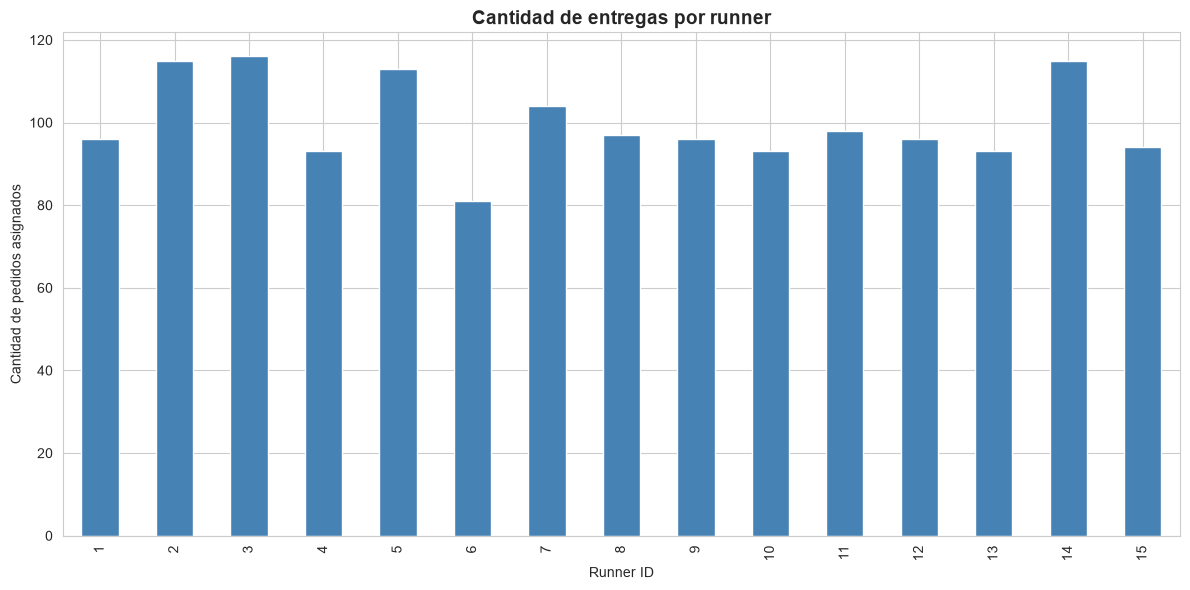

In [33]:
# 1. Cantidad de entregas por runner
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
runner_delivery_details["runner_id"].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Cantidad de entregas por runner", fontsize=14, fontweight="bold")
ax.set_xlabel("Runner ID")
ax.set_ylabel("Cantidad de pedidos asignados")
plt.tight_layout()
plt.show()

,runner_id,avg_duration_minutes,total_deliveries


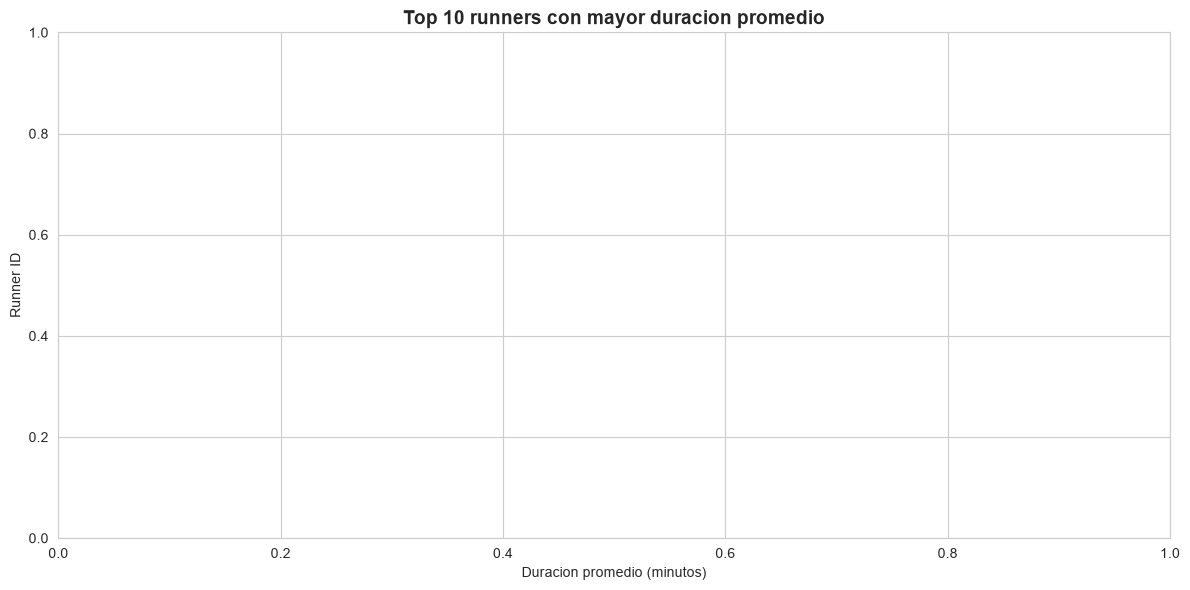

In [34]:
# 2. Top 10 runners que mas tardan en entregar pedidos
completed_deliveries = runner_delivery_details[~runner_delivery_details["is_cancelled"]].copy()

top_10_slowest_runners = (
    completed_deliveries.groupby("runner_id", as_index=False)
    .agg(
        avg_duration_minutes=("duration_minutes", "mean"),
        total_deliveries=("order_id", "count"),
    )
    .sort_values("avg_duration_minutes", ascending=False)
    .head(10)
)

display(top_10_slowest_runners)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
sns.barplot(data=top_10_slowest_runners, x="avg_duration_minutes", y="runner_id", orient="h", ax=ax, color="coral")
ax.set_title("Top 10 runners con mayor duracion promedio", fontsize=14, fontweight="bold")
ax.set_xlabel("Duracion promedio (minutos)")
ax.set_ylabel("Runner ID")
plt.tight_layout()
plt.show()

,runner_tenure_years,duration_minutes
runner_tenure_years,NaN,NaN
duration_minutes,NaN,NaN


c:\Users\GJLG\Repositorios\Inteligencia artificial avanzada\Inteligencia-artificial-avanzada\.venv\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\GJLG\Repositorios\Inteligencia artificial avanzada\Inteligencia-artificial-avanzada\.venv\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


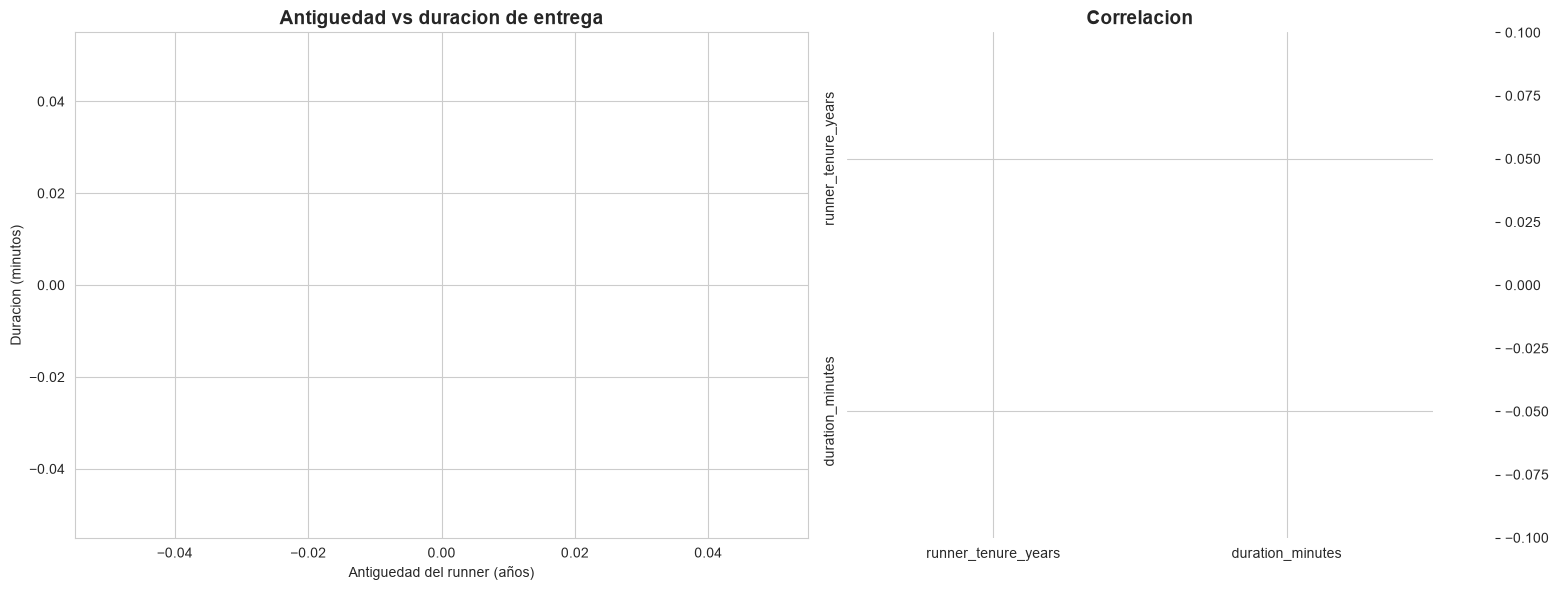

In [35]:
# 3. Relacion entre antiguedad del runner y duracion de entrega
correlation_data = completed_deliveries[["runner_tenure_years", "duration_minutes"]].dropna()
runner_tenure_duration_corr = correlation_data.corr()

display(runner_tenure_duration_corr)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.regplot(
    data=correlation_data,
    x="runner_tenure_years",
    y="duration_minutes",
    scatter_kws={"alpha": 0.35},
    line_kws={"color": "crimson"},
    ax=axes[0],
)
axes[0].set_title("Antiguedad vs duracion de entrega", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Antiguedad del runner (años)")
axes[0].set_ylabel("Duracion (minutos)")

sns.heatmap(runner_tenure_duration_corr, annot=True, cmap="RdBu_r", center=0, ax=axes[1])
axes[1].set_title("Correlacion", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

,cancellation,cantidad
0,no_cancelado,1450
1,customer_no_show,16
2,address_issue,13
3,runner_sick,7
4,order_late,7
5,runner_unavailable,5
6,restaurant_cancelled,2


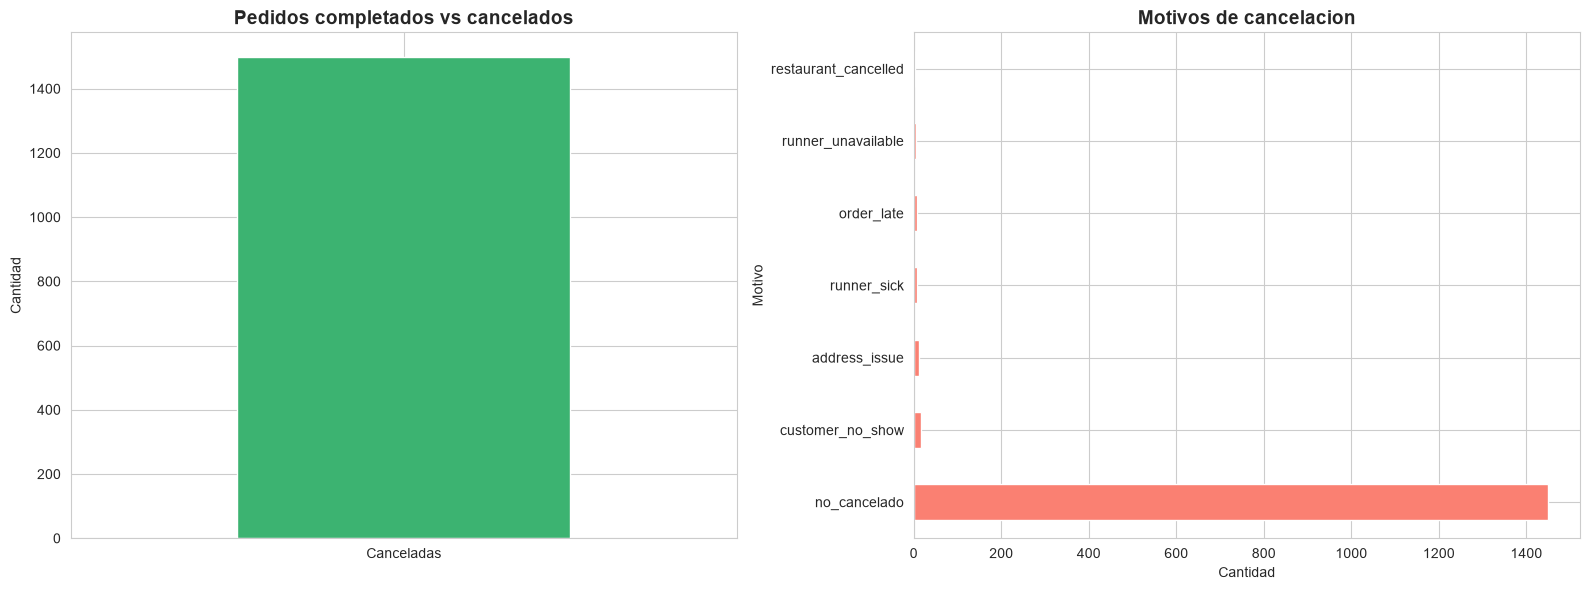

In [36]:
# Graficas de cancelaciones
cancellation_counts = runner_delivery_details["cancellation_clean"].value_counts()
display(cancellation_counts.rename_axis("cancellation").reset_index(name="cantidad"))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
runner_delivery_details["is_cancelled"].value_counts().rename({False: "Completadas", True: "Canceladas"}).plot(
    kind="bar",
    ax=axes[0],
    color=["mediumseagreen", "salmon"],
)
axes[0].set_title("Pedidos completados vs cancelados", fontsize=14, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis="x", rotation=0)

cancellation_counts.drop(labels="completed", errors="ignore").plot(kind="barh", ax=axes[1], color="salmon")
axes[1].set_title("Motivos de cancelacion", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Cantidad")
axes[1].set_ylabel("Motivo")
plt.tight_layout()
plt.show()

,time_block,cantidad
0,Mañana (6am-12pm),198
1,Tarde (12pm-6pm),364
2,Noche (6pm-12am),654
3,Madrugada (12am-6am),201
4,Sin pickup,83


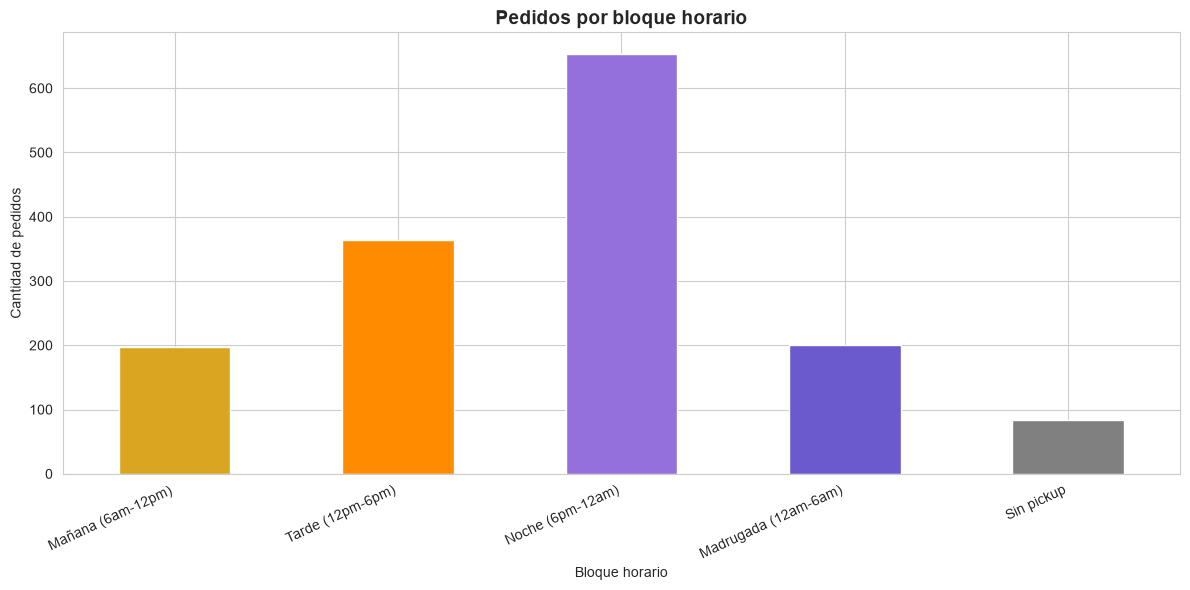

In [37]:
# Entregas por bloque horario
time_block_order = ["Mañana (6am-12pm)", "Tarde (12pm-6pm)", "Noche (6pm-12am)", "Madrugada (12am-6am)", "Sin pickup"]
time_block_counts = runner_delivery_details["time_block"].value_counts().reindex(time_block_order, fill_value=0)

display(time_block_counts.rename_axis("time_block").reset_index(name="cantidad"))

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
time_block_counts.plot(kind="bar", ax=ax, color=["goldenrod", "darkorange", "mediumpurple", "slateblue", "gray"])
ax.set_title("Pedidos por bloque horario", fontsize=14, fontweight="bold")
ax.set_xlabel("Bloque horario")
ax.set_ylabel("Cantidad de pedidos")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

,no_esta_en_receta_base,esta_en_receta_base
tipo_modificacion,,
Agregado,753,0
Quitado,0,684


,topping_name,tipo_modificacion,cantidad
27,Tomato Sauce,Quitado,166
16,Mozzarella,Quitado,155
14,Jalapeno,Agregado,84
8,Chicken,Agregado,67
10,Fresh Basil,Agregado,67
24,Pepperoni,Quitado,66
6,Bell Pepper,Agregado,65
12,Garlic,Agregado,59
17,Mushroom,Agregado,56
21,Onion,Agregado,55


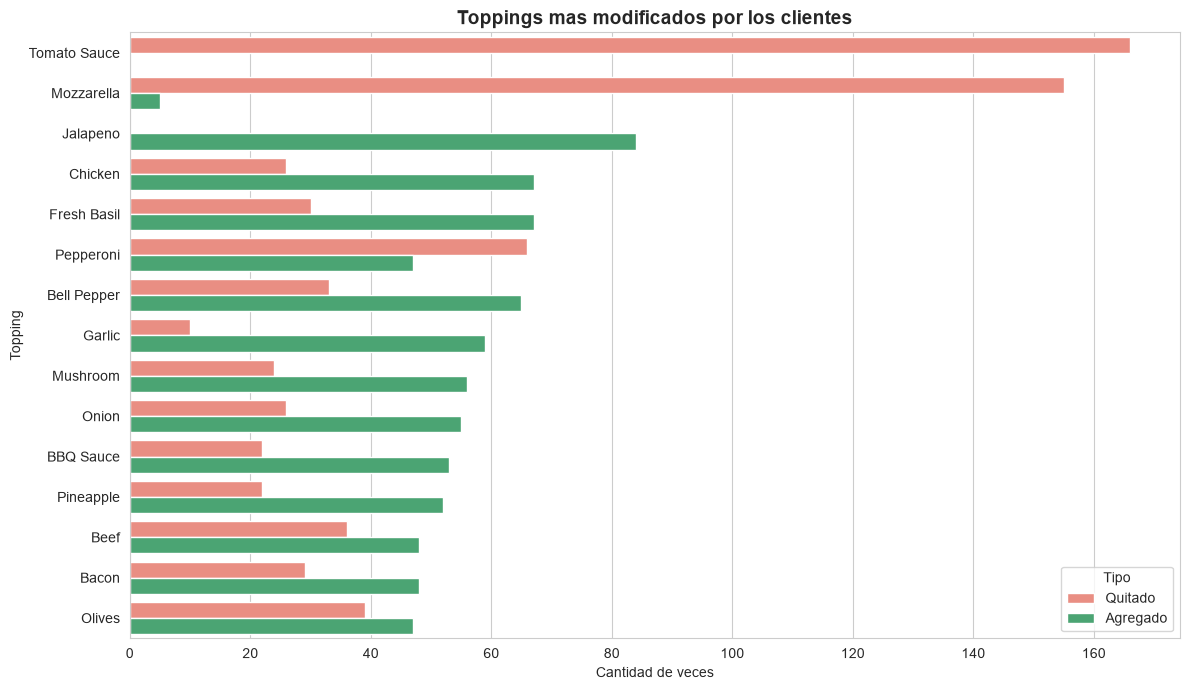

In [38]:
# Top toppings modificados por los clientes: ingredientes quitados vs agregados
def separar_topping_ids(valor):
    if pd.isna(valor):
        return []

    valor = str(valor).strip()
    if valor == "":
        return []

    return [int(topping_id.strip()) for topping_id in valor.split(",") if topping_id.strip()]


def preparar_modificaciones_toppings(df, columna, tipo_modificacion):
    modificaciones = df[["order_id", "pizza_id", "pizza_name", columna]].copy()
    modificaciones["topping_id"] = modificaciones[columna].apply(separar_topping_ids)
    modificaciones = modificaciones.explode("topping_id").dropna(subset=["topping_id"])

    if modificaciones.empty:
        return pd.DataFrame(columns=["order_id", "pizza_id", "pizza_name", "topping_id", "topping_name", "tipo_modificacion"])

    modificaciones["topping_id"] = modificaciones["topping_id"].astype(int)
    modificaciones["tipo_modificacion"] = tipo_modificacion
    modificaciones = modificaciones.merge(pizza_toppings, on="topping_id", how="left")
    return modificaciones[["order_id", "pizza_id", "pizza_name", "topping_id", "topping_name", "tipo_modificacion"]]


toppings_quitados = preparar_modificaciones_toppings(orders_with_pizza_names, "exclusions", "Quitado")
toppings_agregados = preparar_modificaciones_toppings(orders_with_pizza_names, "extras", "Agregado")
toppings_modificados = pd.concat([toppings_quitados, toppings_agregados], ignore_index=True)

receta_base_toppings = (
    pizza_recipes.assign(topping_id=pizza_recipes["toppings"].str.split(","))
    .explode("topping_id")
    .drop(columns="toppings")
)
receta_base_toppings["topping_id"] = receta_base_toppings["topping_id"].astype(int)
receta_base_toppings["esta_en_receta_base"] = True

toppings_modificados = toppings_modificados.merge(
    receta_base_toppings[["pizza_id", "topping_id", "esta_en_receta_base"]],
    on=["pizza_id", "topping_id"],
    how="left",
)
toppings_modificados["esta_en_receta_base"] = toppings_modificados["esta_en_receta_base"].eq(True)

toppings_quitados = toppings_modificados[toppings_modificados["tipo_modificacion"] == "Quitado"].copy()
toppings_agregados = toppings_modificados[toppings_modificados["tipo_modificacion"] == "Agregado"].copy()

validacion_modificaciones = pd.crosstab(
    toppings_modificados["tipo_modificacion"],
    toppings_modificados["esta_en_receta_base"],
)
validacion_modificaciones.columns = ["no_esta_en_receta_base", "esta_en_receta_base"]
display(validacion_modificaciones)

toppings_mas_modificados = (
    toppings_modificados
    .groupby(["topping_name", "tipo_modificacion"], as_index=False)
    .size()
    .rename(columns={"size": "cantidad"})
    .sort_values("cantidad", ascending=False)
)

display(toppings_mas_modificados)

fig, ax = plt.subplots(1, 1, figsize=(12, 7))
sns.barplot(
    data=toppings_mas_modificados,
    x="cantidad",
    y="topping_name",
    hue="tipo_modificacion",
    ax=ax,
    palette={"Quitado": "salmon", "Agregado": "mediumseagreen"},
)
ax.set_title("Toppings mas modificados por los clientes", fontsize=14, fontweight="bold")
ax.set_xlabel("Cantidad de veces")
ax.set_ylabel("Topping")
ax.legend(title="Tipo")
plt.tight_layout()
plt.show()

### Metodo del analisis de toppings

La receta base de cada pizza viene de `pizza_recipes`. Las columnas `exclusions` y `extras` de `customer_orders` contienen IDs de ingredientes modificados por el cliente.

- Para `exclusions`, se valida que el ingrediente pertenezca a la receta base de esa pizza, porque solo tiene sentido quitar algo que ya venia incluido.
- Para `extras`, se compara contra la receta base para saber si el cliente esta agregando un ingrediente que no venia en esa pizza.
- El heatmap se construye por `pizza_name` y por `topping_name`, pero los nombres salen despues de traducir los IDs con `pizza_toppings`.

En la validacion actual, todos los ingredientes quitados estan en la receta base y todos los ingredientes agregados no estan en la receta base de la pizza correspondiente.


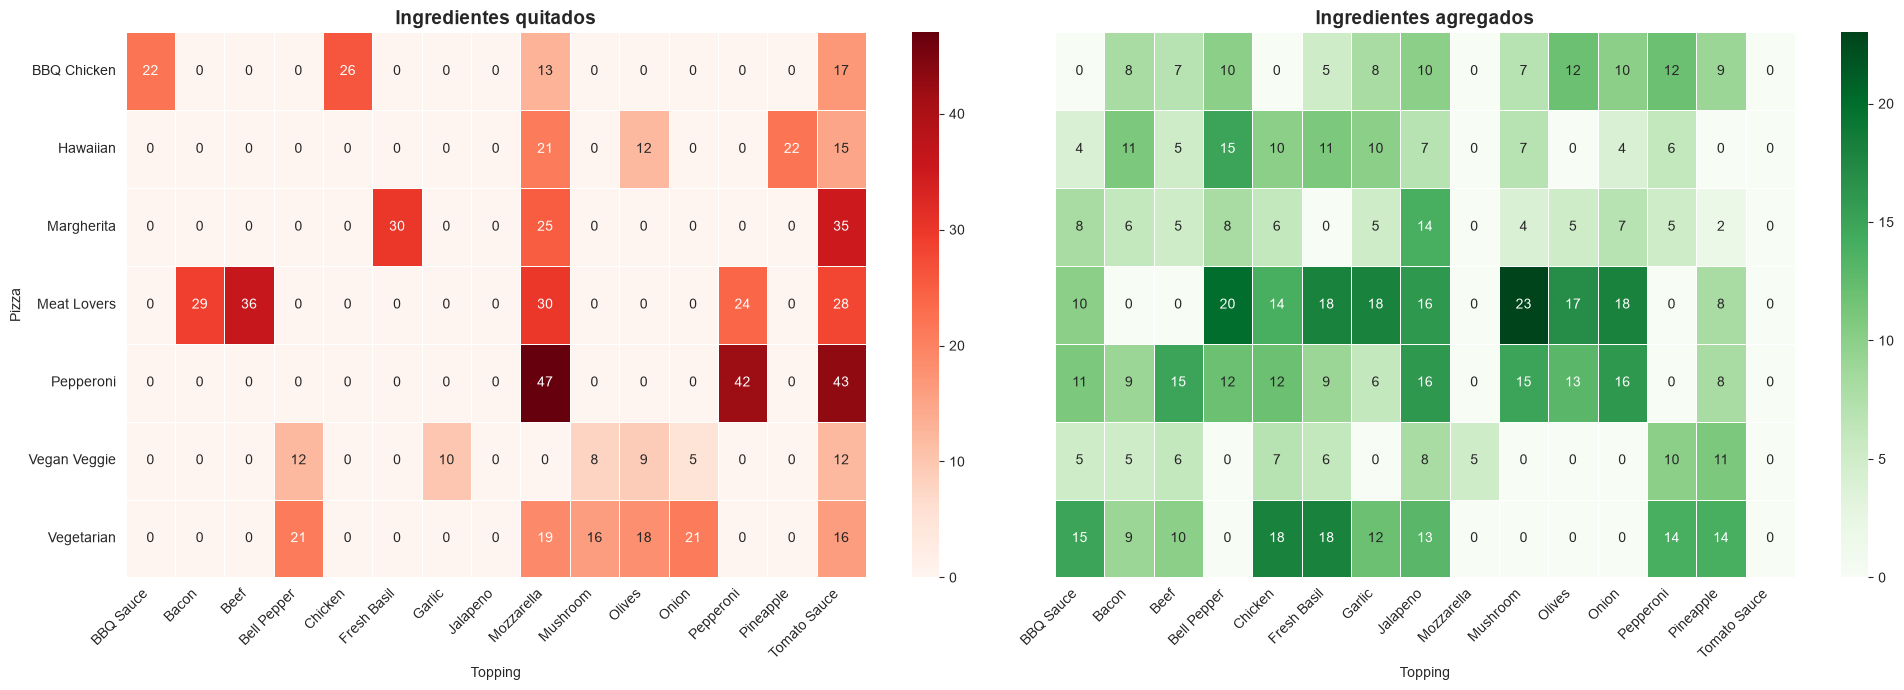

In [39]:
# Heatmap de modificaciones: que ingredientes quitan y agregan segun la pizza ordenada
matriz_quitados = pd.crosstab(
    toppings_quitados["pizza_name"],
    toppings_quitados["topping_name"],
)

matriz_agregados = pd.crosstab(
    toppings_agregados["pizza_name"],
    toppings_agregados["topping_name"],
)

columnas_toppings = sorted(set(matriz_quitados.columns).union(set(matriz_agregados.columns)))
pizzas = sorted(set(matriz_quitados.index).union(set(matriz_agregados.index)))
matriz_quitados = matriz_quitados.reindex(index=pizzas, columns=columnas_toppings, fill_value=0)
matriz_agregados = matriz_agregados.reindex(index=pizzas, columns=columnas_toppings, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)
sns.heatmap(
    matriz_quitados,
    annot=True,
    fmt="d",
    cmap="Reds",
    linewidths=0.5,
    ax=axes[0],
)
axes[0].set_title("Ingredientes quitados", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Topping")
axes[0].set_ylabel("Pizza")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(
    matriz_agregados,
    annot=True,
    fmt="d",
    cmap="Greens",
    linewidths=0.5,
    ax=axes[1],
)
axes[1].set_title("Ingredientes agregados", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Topping")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=45)

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), ha="right")

plt.tight_layout()
plt.show()

topping_name,Tomato Sauce,Mozzarella,Mushroom,Onion,Bell Pepper,Olives,Pepperoni,Bacon,Beef,Chicken,Pineapple,BBQ Sauce,Jalapeno,Fresh Basil,Garlic
pizza_name,,,,,,,,,,,,,,,
Margherita,0,0,4,7,8,5,5,6,5,6,2,8,14,0,5
Vegetarian,0,0,0,0,0,0,14,9,10,18,14,15,13,18,12
Meat Lovers,0,0,23,18,20,17,0,0,0,14,8,10,16,18,18
BBQ Chicken,0,0,7,10,10,12,12,8,7,0,9,0,10,5,8
Hawaiian,0,0,7,4,15,0,6,11,5,10,0,4,7,11,10
Pepperoni,0,0,15,16,12,13,0,9,15,12,8,11,16,9,6
Vegan Veggie,0,5,0,0,0,0,10,5,6,7,11,5,8,6,0


topping_name,Tomato Sauce,Mozzarella,Mushroom,Onion,Bell Pepper,Olives,Pepperoni,Bacon,Beef,Chicken,Pineapple,BBQ Sauce,Jalapeno,Fresh Basil,Garlic
pizza_name,,,,,,,,,,,,,,,
Margherita,35,25,0,0,0,0,0,0,0,0,0,0,0,30,0
Vegetarian,16,19,16,21,21,18,0,0,0,0,0,0,0,0,0
Meat Lovers,28,30,0,0,0,0,24,29,36,0,0,0,0,0,0
BBQ Chicken,17,13,0,0,0,0,0,0,0,26,0,22,0,0,0
Hawaiian,15,21,0,0,0,12,0,0,0,0,22,0,0,0,0
Pepperoni,43,47,0,0,0,0,42,0,0,0,0,0,0,0,0
Vegan Veggie,12,0,8,5,12,9,0,0,0,0,0,0,0,0,10


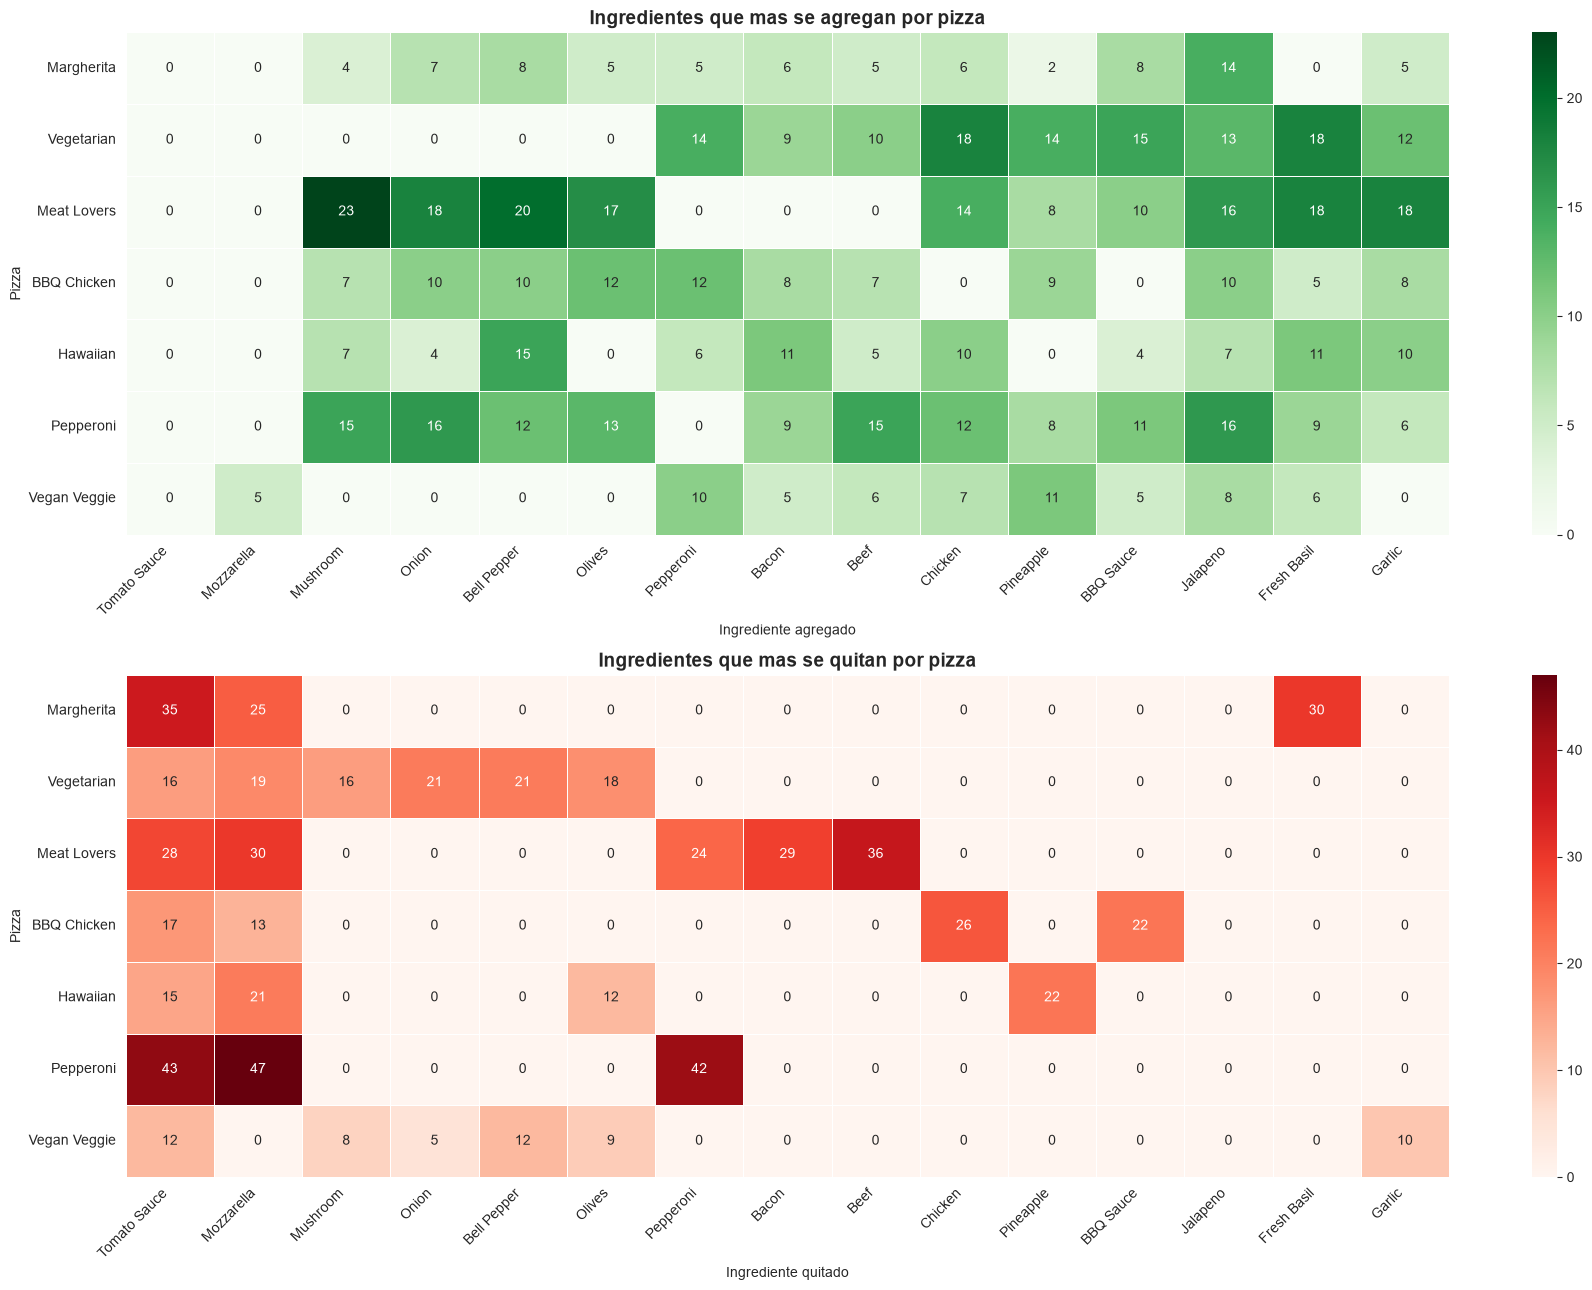

In [40]:
# Heatmaps enfocados: todos los ingredientes que se agregan y se quitan por pizza
def matriz_modificaciones_todos_los_toppings(datos):
    matriz = pd.crosstab(datos["pizza_name"], datos["topping_name"])
    columnas_toppings = pizza_toppings["topping_name"].tolist()
    pizzas = pizza_names["pizza_name"].tolist()
    return matriz.reindex(index=pizzas, columns=columnas_toppings, fill_value=0)


heatmap_agregados_por_pizza = matriz_modificaciones_todos_los_toppings(toppings_agregados)
heatmap_quitados_por_pizza = matriz_modificaciones_todos_los_toppings(toppings_quitados)

display(heatmap_agregados_por_pizza)
display(heatmap_quitados_por_pizza)

fig, axes = plt.subplots(2, 1, figsize=(18, 13))

sns.heatmap(
    heatmap_agregados_por_pizza,
    annot=True,
    fmt="d",
    cmap="Greens",
    linewidths=0.5,
    ax=axes[0],
)
axes[0].set_title("Ingredientes que mas se agregan por pizza", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Ingrediente agregado")
axes[0].set_ylabel("Pizza")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")

sns.heatmap(
    heatmap_quitados_por_pizza,
    annot=True,
    fmt="d",
    cmap="Reds",
    linewidths=0.5,
    ax=axes[1],
)
axes[1].set_title("Ingredientes que mas se quitan por pizza", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Ingrediente quitado")
axes[1].set_ylabel("Pizza")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()


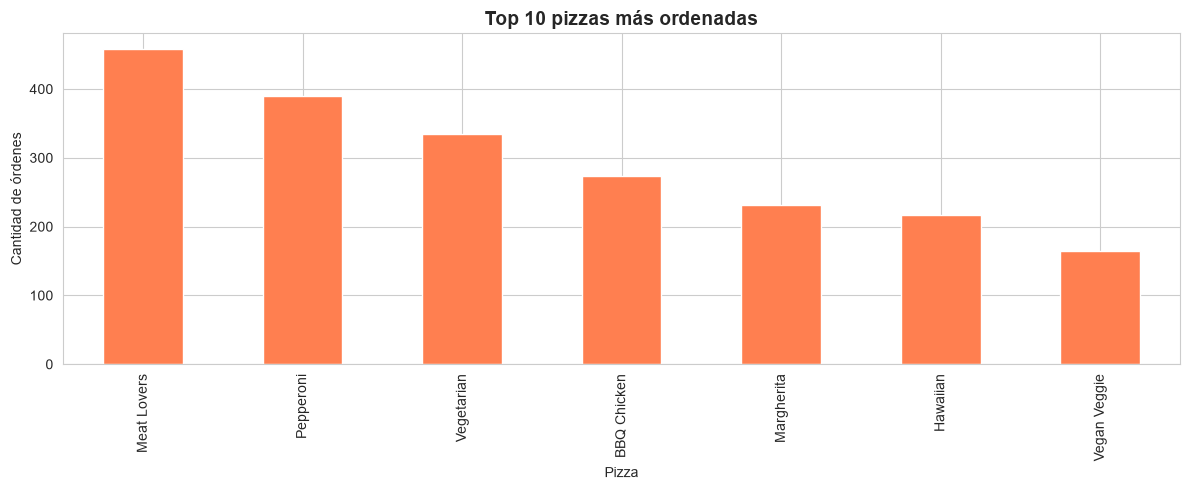

In [41]:
# 2. Pizzas más ordenadas
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
orders_with_pizza_names['pizza_name'].value_counts().head(10).plot(kind='bar', ax=ax, color='coral')
ax.set_title('Top 10 pizzas más ordenadas', fontsize=14, fontweight='bold')
ax.set_xlabel('Pizza')
ax.set_ylabel('Cantidad de órdenes')
plt.tight_layout()
plt.show()

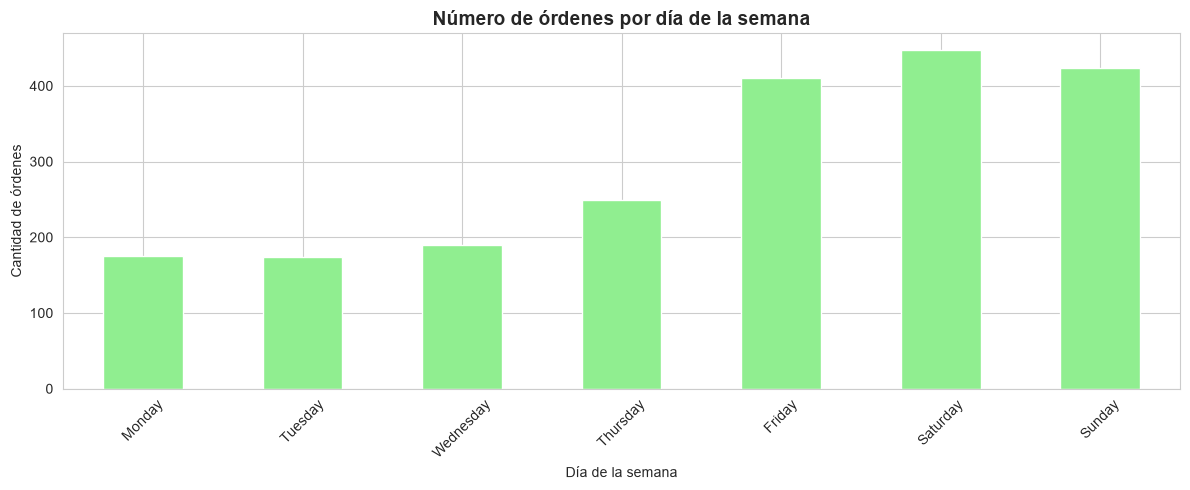

In [42]:
# 3. Órdenes por día de la semana
customer_orders['order_date'] = pd.to_datetime(customer_orders['order_date'])
customer_orders['day_of_week'] = customer_orders['order_date'].dt.day_name()

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
orders_by_day = customer_orders['day_of_week'].value_counts().reindex(day_order)
orders_by_day.plot(kind='bar', ax=ax, color='lightgreen')
ax.set_title('Número de órdenes por día de la semana', fontsize=14, fontweight='bold')
ax.set_xlabel('Día de la semana')
ax.set_ylabel('Cantidad de órdenes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

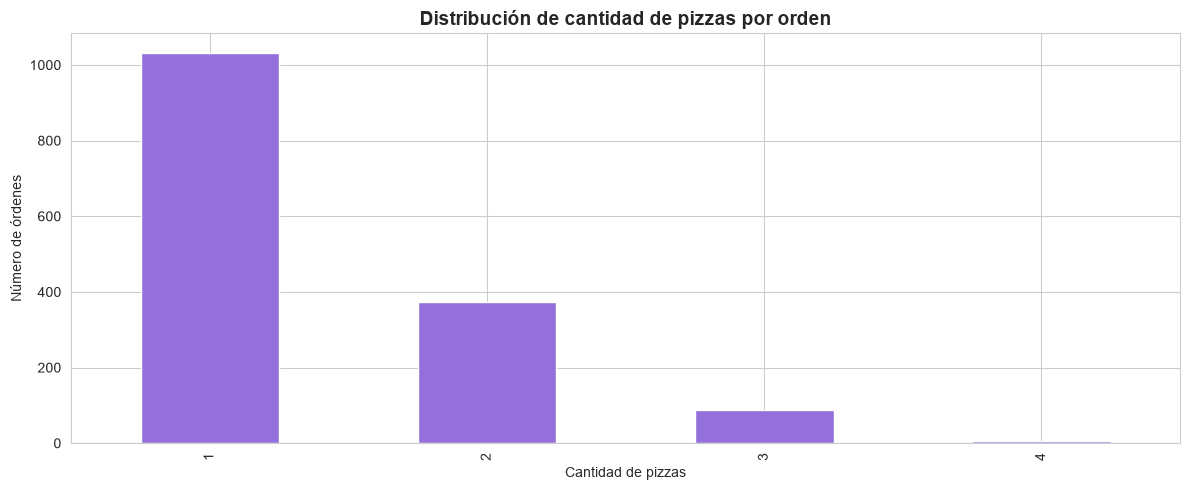

In [43]:
# 4. Distribución de cantidad de pizzas por orden
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
pizzas_por_orden = customer_orders.groupby('order_id').size()
pizzas_por_orden.value_counts().sort_index().plot(kind='bar', ax=ax, color='mediumpurple')
ax.set_title('Distribución de cantidad de pizzas por orden', fontsize=14, fontweight='bold')
ax.set_xlabel('Cantidad de pizzas')
ax.set_ylabel('Número de órdenes')
plt.tight_layout()
plt.show()

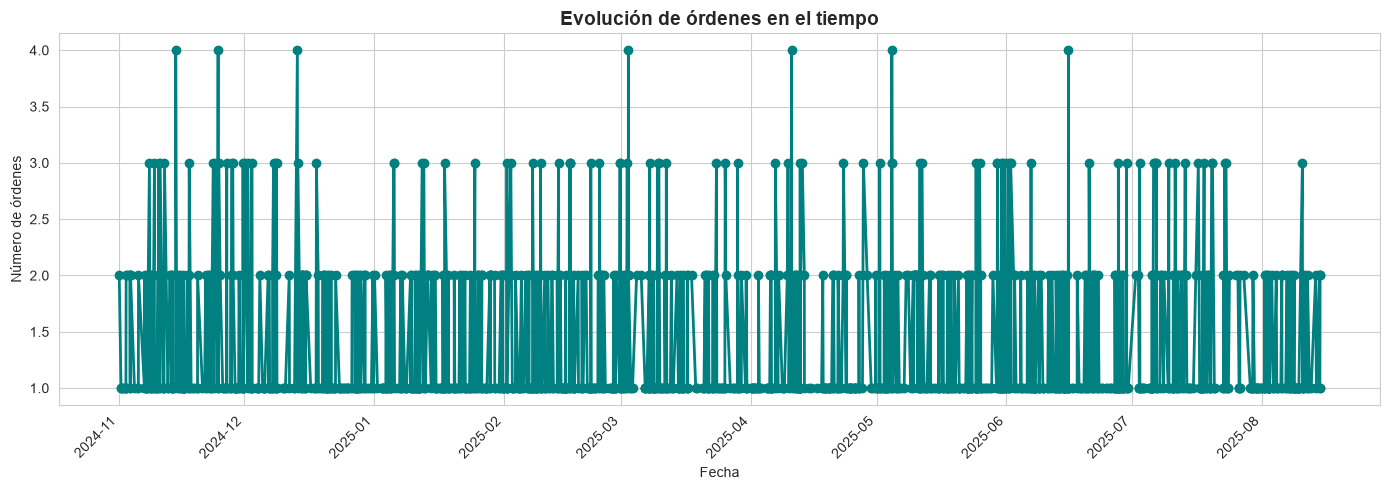

In [44]:
# 5. Órdenes por fecha (tendencia temporal)
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
orders_by_date = customer_orders.groupby('order_date').size()
orders_by_date.plot(ax=ax, color='teal', linewidth=2, marker='o')
ax.set_title('Evolución de órdenes en el tiempo', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Número de órdenes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Analisis de fidelidad de clientes

Este bloque separa el analisis por anio para no mezclar los pedidos de 2024 y 2025. Se cuentan ordenes unicas y pizzas por separado porque una orden puede incluir mas de una pizza.


In [45]:
# Preparacion de datos para fidelidad de clientes
orders_fidelidad = customer_orders.copy()
orders_fidelidad["order_date"] = pd.to_datetime(orders_fidelidad["order_date"], errors="coerce")
orders_fidelidad["year"] = orders_fidelidad["order_date"].dt.year
orders_fidelidad["month"] = orders_fidelidad["order_date"].dt.to_period("M").astype(str)
orders_fidelidad["date"] = orders_fidelidad["order_date"].dt.date

orders_fidelidad = orders_fidelidad.merge(pizza_names, on="pizza_id", how="left")

print("Rango de fechas en customer_orders:")
print(orders_fidelidad["order_date"].min(), "a", orders_fidelidad["order_date"].max())
orders_fidelidad.head()


Rango de fechas en customer_orders:
2024-11-01 04:07:33 a 2025-08-14 20:52:11


,order_id,customer_id,pizza_id,exclusions,extras,order_date,day_of_week,year,month,date,pizza_name
0,2481,500,2,NaN,NaN,2025-02-21 16:06:46,Friday,2025,2025-02,2025-02-21,Vegetarian
1,1897,269,6,NaN,NaN,2025-08-12 08:27:50,Tuesday,2025,2025-08,2025-08-12,Pepperoni
2,1842,59,7,NaN,NaN,2024-12-23 20:50:23,Monday,2024,2024-12,2024-12-23,Vegan Veggie
3,1869,710,6,NaN,NaN,2025-01-31 09:16:49,Friday,2025,2025-01,2025-01-31,Pepperoni
4,2384,189,3,NaN,NaN,2024-11-30 17:35:37,Saturday,2024,2024-11,2024-11-30,Meat Lovers


In [46]:
# Fidelidad por cliente y por anio
fidelidad_clientes_anio = (
    orders_fidelidad
    .groupby(["year", "customer_id"])
    .agg(
        total_pizzas=("pizza_id", "count"),
        total_ordenes=("order_id", "nunique"),
        dias_con_pedido=("date", "nunique"),
        primera_orden=("order_date", "min"),
        ultima_orden=("order_date", "max"),
        tipos_pizza_distintos=("pizza_name", "nunique"),
    )
    .reset_index()
)

fidelidad_clientes_anio["pizzas_por_orden"] = (
    fidelidad_clientes_anio["total_pizzas"] / fidelidad_clientes_anio["total_ordenes"]
).round(2)
fidelidad_clientes_anio["cliente_recurrente"] = fidelidad_clientes_anio["total_ordenes"] >= 2

fidelidad_clientes_anio = fidelidad_clientes_anio.sort_values(
    ["year", "total_ordenes", "total_pizzas", "dias_con_pedido"],
    ascending=[True, False, False, False]
)

fidelidad_clientes_anio.head(10)


,year,customer_id,total_pizzas,total_ordenes,dias_con_pedido,primera_orden,ultima_orden,tipos_pizza_distintos,pizzas_por_orden,cliente_recurrente
127,2024,500,19,12,10,2024-11-01 04:07:33,2024-12-14 21:33:46,7,1.58,True
43,2024,180,13,9,8,2024-11-03 17:07:37,2024-12-28 19:18:53,6,1.44,True
140,2024,547,12,8,8,2024-11-07 19:01:36,2024-12-30 18:13:41,6,1.50,True
180,2024,730,10,8,8,2024-11-07 09:42:44,2024-12-31 17:34:26,5,1.25,True
8,2024,30,9,7,7,2024-11-05 18:20:28,2024-12-26 18:24:17,4,1.29,True
12,2024,45,12,6,6,2024-11-03 12:16:30,2024-12-27 20:24:47,7,2.00,True
186,2024,755,10,6,6,2024-11-03 19:40:09,2024-12-25 18:15:25,5,1.67,True
96,2024,400,8,6,6,2024-11-10 14:48:45,2024-12-08 01:24:53,5,1.33,True
156,2024,657,9,5,5,2024-11-02 23:50:57,2024-12-20 21:51:53,5,1.80,True
163,2024,667,9,5,4,2024-11-17 02:10:55,2024-12-13 19:39:18,5,1.80,True


In [47]:
# Top 10 mejores clientes por anio
top_10_clientes_por_anio = (
    fidelidad_clientes_anio
    .sort_values(
        ["year", "total_ordenes", "total_pizzas", "dias_con_pedido"],
        ascending=[True, False, False, False]
    )
    .groupby("year")
    .head(10)
    .reset_index(drop=True)
)

display(top_10_clientes_por_anio)


,year,customer_id,total_pizzas,total_ordenes,dias_con_pedido,primera_orden,ultima_orden,tipos_pizza_distintos,pizzas_por_orden,cliente_recurrente
0,2024,500,19,12,10,2024-11-01 04:07:33,2024-12-14 21:33:46,7,1.58,True
1,2024,180,13,9,8,2024-11-03 17:07:37,2024-12-28 19:18:53,6,1.44,True
2,2024,547,12,8,8,2024-11-07 19:01:36,2024-12-30 18:13:41,6,1.50,True
3,2024,730,10,8,8,2024-11-07 09:42:44,2024-12-31 17:34:26,5,1.25,True
4,2024,30,9,7,7,2024-11-05 18:20:28,2024-12-26 18:24:17,4,1.29,True
5,2024,45,12,6,6,2024-11-03 12:16:30,2024-12-27 20:24:47,7,2.00,True
6,2024,755,10,6,6,2024-11-03 19:40:09,2024-12-25 18:15:25,5,1.67,True
7,2024,400,8,6,6,2024-11-10 14:48:45,2024-12-08 01:24:53,5,1.33,True
8,2024,657,9,5,5,2024-11-02 23:50:57,2024-12-20 21:51:53,5,1.80,True
9,2024,667,9,5,4,2024-11-17 02:10:55,2024-12-13 19:39:18,5,1.80,True


In [48]:
# Top 10 mejores clientes globales, considerando 2024 y 2025
top_10_clientes_global = (
    fidelidad_clientes_anio
    .groupby("customer_id")
    .agg(
        total_pizzas=("total_pizzas", "sum"),
        total_ordenes=("total_ordenes", "sum"),
        dias_con_pedido=("dias_con_pedido", "sum"),
        primera_orden=("primera_orden", "min"),
        ultima_orden=("ultima_orden", "max"),
        anios_activo=("year", "nunique"),
    )
    .reset_index()
)

top_10_clientes_global["pizzas_por_orden"] = (
    top_10_clientes_global["total_pizzas"] / top_10_clientes_global["total_ordenes"]
).round(2)

top_10_clientes_global = top_10_clientes_global.sort_values(
    ["total_ordenes", "total_pizzas", "dias_con_pedido"],
    ascending=False
).head(10)

display(top_10_clientes_global)


,customer_id,total_pizzas,total_ordenes,dias_con_pedido,primera_orden,ultima_orden,anios_activo,pizzas_por_orden
367,500,52,36,34,2024-11-01 04:07:33,2025-08-08 17:11:29,2,1.44
24,30,51,36,35,2024-11-05 18:20:28,2025-08-11 17:03:54,2,1.42
512,717,51,36,35,2024-11-02 18:22:21,2025-08-05 17:29:39,2,1.42
522,730,51,35,35,2024-11-07 09:42:44,2025-08-13 19:55:37,2,1.46
445,620,58,34,33,2024-11-09 13:33:16,2025-08-01 03:42:12,2,1.71
394,547,48,34,32,2024-11-07 19:01:36,2025-08-01 19:41:43,2,1.41
467,657,51,33,33,2024-11-02 23:50:57,2025-08-10 19:50:30,2,1.55
137,180,48,33,30,2024-11-03 17:07:37,2025-08-08 13:58:17,2,1.45
183,240,47,31,30,2024-12-19 01:26:30,2025-08-14 18:50:00,2,1.52
540,755,44,31,30,2024-11-03 19:40:09,2025-07-30 16:35:51,2,1.42


In [49]:
# Crecimiento de ordenes, pizzas y clientes por anio
crecimiento_anual = (
    orders_fidelidad
    .groupby("year")
    .agg(
        total_ordenes=("order_id", "nunique"),
        total_pizzas=("pizza_id", "count"),
        clientes_unicos=("customer_id", "nunique"),
    )
    .reset_index()
    .sort_values("year")
)

clientes_recurrentes = (
    fidelidad_clientes_anio
    .groupby("year")["cliente_recurrente"]
    .sum()
    .reset_index(name="clientes_recurrentes")
)

crecimiento_anual = crecimiento_anual.merge(clientes_recurrentes, on="year", how="left")
crecimiento_anual["ordenes_por_cliente"] = (
    crecimiento_anual["total_ordenes"] / crecimiento_anual["clientes_unicos"]
).round(2)
crecimiento_anual["pizzas_por_cliente"] = (
    crecimiento_anual["total_pizzas"] / crecimiento_anual["clientes_unicos"]
).round(2)
crecimiento_anual["pct_clientes_recurrentes"] = (
    crecimiento_anual["clientes_recurrentes"] / crecimiento_anual["clientes_unicos"] * 100
).round(2)

for columna in ["total_ordenes", "total_pizzas", "clientes_unicos", "clientes_recurrentes"]:
    crecimiento_anual[f"crecimiento_{columna}_pct"] = crecimiento_anual[columna].pct_change().mul(100).round(2)

display(crecimiento_anual)


,year,total_ordenes,total_pizzas,clientes_unicos,clientes_recurrentes,ordenes_por_cliente,pizzas_por_cliente,pct_clientes_recurrentes,crecimiento_total_ordenes_pct,crecimiento_total_pizzas_pct,crecimiento_clientes_unicos_pct,crecimiento_clientes_recurrentes_pct
0,2024,299,427,196,37,1.53,2.18,18.88,NaN,NaN,NaN,NaN
1,2025,1201,1643,502,218,2.39,3.27,43.43,301.67,284.78,156.12,489.19


,year,month,total_ordenes,total_pizzas,clientes_unicos
0,2024,2024-11,152,224,112
1,2024,2024-12,147,203,108
2,2025,2025-01,172,234,120
3,2025,2025-02,173,239,126
4,2025,2025-03,145,199,109
5,2025,2025-04,138,184,99
6,2025,2025-05,179,251,130
7,2025,2025-06,169,226,104
8,2025,2025-07,144,206,105
9,2025,2025-08,81,104,62


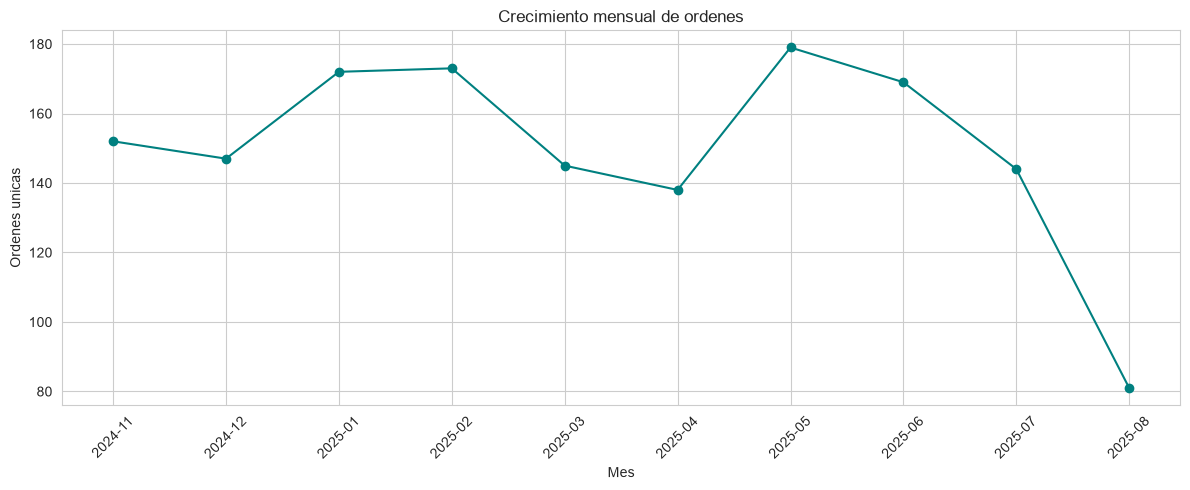

In [50]:
# Evolucion mensual para observar tendencia de crecimiento
crecimiento_mensual = (
    orders_fidelidad
    .groupby(["year", "month"])
    .agg(
        total_ordenes=("order_id", "nunique"),
        total_pizzas=("pizza_id", "count"),
        clientes_unicos=("customer_id", "nunique"),
    )
    .reset_index()
    .sort_values(["year", "month"])
)

display(crecimiento_mensual)

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(crecimiento_mensual["month"], crecimiento_mensual["total_ordenes"], marker="o", color="teal")
ax.set_title("Crecimiento mensual de ordenes")
ax.set_xlabel("Mes")
ax.set_ylabel("Ordenes unicas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [51]:
# Pizzas favoritas de los top 10 clientes globales
preferencias_top_clientes = (
    orders_fidelidad[orders_fidelidad["customer_id"].isin(top_10_clientes_global["customer_id"])]
    .groupby(["customer_id", "pizza_name"])
    .size()
    .reset_index(name="cantidad")
    .sort_values(["customer_id", "cantidad"], ascending=[True, False])
)

display(preferencias_top_clientes)


,customer_id,pizza_name,cantidad
4,30,Pepperoni,15
6,30,Vegetarian,11
3,30,Meat Lovers,8
0,30,BBQ Chicken,7
5,30,Vegan Veggie,5
...,...,...,...
63,755,BBQ Chicken,8
67,755,Pepperoni,6
65,755,Margherita,4
64,755,Hawaiian,3


Nota para interpretar el crecimiento: los datos de 2024 empiezan en noviembre, mientras que 2025 llega hasta agosto. Por eso, la comparacion anual muestra crecimiento, pero 2024 no representa un anio completo.
